# KS VAE LoRA fine-tuning

This notebook only trains LoRA adapters on the pretrained FLUX.2 Klein VAE. Every optimizer step consumes freshly simulated Kuramoto--Sivashinsky initial-condition panels and solution trajectories. Set `flux_aware_loss` to enable the composite RGB, physical, unstable-mode Fourier, derivative, and latent-anchor objective; disabling it restores pixel-space reconstruction MSE. Debug updates report physical reconstruction error on 50 fixed held-out samples.

In [ ]:
import json
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from diffusers import Flux2KleinPipeline
from diffusers.loaders.lora_base import LORA_ADAPTER_METADATA_KEY
from diffusers.models import AutoencoderKLFlux2
from IPython.display import clear_output
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from safetensors.torch import save_file
from torch.utils.data import DataLoader, Dataset, IterableDataset, get_worker_info

from generative_physics.ks import (
    KS_CONDITION_ENCODING,
    KS_DOMAIN_LENGTH,
    KS_GRID_SIZE,
    KS_INITIAL_NUM_MODES,
    KS_VALUE_BOUNDS,
    generate_ks_image_pairs,
)
from generative_physics.rendering import rgb_image_to_model_tensor


@dataclass
class VaeLoraConfig:
    model_id: str = "black-forest-labs/FLUX.2-klein-4B"
    output_dir: str = "ks_vae_lora"
    image_size: int = 256
    condition_encoding: str = KS_CONDITION_ENCODING
    batch_size: int = 1  # KS pairs per step; the VAE sees 2 * batch_size images
    num_workers: int = 16
    seed_offset: int = 40_000
    max_steps: int = 50_000
    learning_rate: float = 3e-5
    weight_decay: float = 1e-2
    max_grad_norm: float = 1.0
    lora_rank: int = 16
    lora_dropout: float = 0.0
    ema_decay: float = 0.95
    plot_every: int = 200
    save_every: int = 500
    gradient_checkpointing: bool = True
    flux_aware_loss: bool = True
    debug_num_samples: int = 50
    debug_seed_offset: int = 20_000


config = VaeLoraConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dtype = (
    torch.bfloat16
    if device.type == "cuda" and torch.cuda.is_bf16_supported()
    else torch.float32
)
if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True

print(
    f"device={device}, VAE dtype={model_dtype}, output={config.output_dir}, "
    f"condition={config.condition_encoding}, flux_aware_loss={config.flux_aware_loss}"
)

/home/ubuntu/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device=cuda, VAE dtype=torch.bfloat16, output=ks_vae_lora, condition=y_constant, flux_aware_loss=True


In [2]:
class FreshKSPairStream(IterableDataset):
    """An infinite stream in which every item is a newly simulated KS pair."""

    def __init__(self, image_size, seed_offset, condition_encoding):
        self.image_size = int(image_size)
        self.seed_offset = int(seed_offset)
        self.condition_encoding = str(condition_encoding)

    def __iter__(self):
        worker = get_worker_info()
        if worker is None:
            seed, stride = self.seed_offset, 1
        else:
            torch.set_num_threads(1)
            seed = self.seed_offset + worker.id
            stride = worker.num_workers

        while True:
            solution, initial, _ = generate_ks_image_pairs(
                [seed],
                sim_nx=max(KS_GRID_SIZE, self.image_size),
                output_size=self.image_size,
                condition_encoding=self.condition_encoding,
                sim_device="cpu",
            )[0]
            # Both sides of the pair are reconstruction targets.
            yield {
                "pixels": torch.stack(
                    [
                        rgb_image_to_model_tensor(initial),
                        rgb_image_to_model_tensor(solution),
                    ]
                ),
                "seed": seed,
            }
            seed += stride


class FixedKSEvalDataset(Dataset):
    """A deterministic held-out set used for comparable debug metrics."""

    def __init__(self, image_size, seed_offset, num_samples, condition_encoding):
        self.image_size = int(image_size)
        self.seed_offset = int(seed_offset)
        self.num_samples = int(num_samples)
        self.condition_encoding = str(condition_encoding)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        torch.set_num_threads(1)
        seed = self.seed_offset + int(index)
        solution, initial, _ = generate_ks_image_pairs(
            [seed],
            sim_nx=max(KS_GRID_SIZE, self.image_size),
            output_size=self.image_size,
            condition_encoding=self.condition_encoding,
            sim_device="cpu",
        )[0]
        return {
            "pixels": torch.stack(
                [
                    rgb_image_to_model_tensor(initial),
                    rgb_image_to_model_tensor(solution),
                ]
            ),
            "seed": seed,
        }


def make_fixed_eval_batch(cfg):
    dataset = FixedKSEvalDataset(
        cfg.image_size,
        cfg.debug_seed_offset,
        cfg.debug_num_samples,
        cfg.condition_encoding,
    )
    loader = DataLoader(
        dataset,
        batch_size=cfg.debug_num_samples,
        num_workers=min(cfg.num_workers, cfg.debug_num_samples),
        prefetch_factor=1 if cfg.num_workers > 0 else None,
    )
    return next(iter(loader))


def make_loader(cfg):
    kwargs = {}
    if cfg.num_workers > 0:
        kwargs.update(
            num_workers=cfg.num_workers,
            persistent_workers=True,
            prefetch_factor=1,
        )
    return DataLoader(
        FreshKSPairStream(cfg.image_size, cfg.seed_offset, cfg.condition_encoding),
        batch_size=cfg.batch_size,
        pin_memory=device.type == "cuda",
        **kwargs,
    )


def plot_ema_error(ema_errors, decay):
    values = np.asarray(ema_errors, dtype=np.float64)
    upper = float(np.quantile(values, 0.80))
    visible = values[values <= upper]
    lower = float(visible.min()) if visible.size else float(values.min())
    span = max(upper - lower, np.finfo(np.float64).eps)
    adaptive_bottom = max(0.0, lower - 0.05 * span)
    if upper <= adaptive_bottom:
        upper = adaptive_bottom + max(abs(adaptive_bottom) * 0.01, 1e-8)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(np.arange(1, len(values) + 1), values, linewidth=1.5)
    ax.set_ylim(adaptive_bottom, upper)
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("EMA training loss")
    ax.set_title(f"KS VAE LoRA training loss (EMA decay {decay}; top 20% clipped)")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def save_vae_lora_adapter(vae, save_directory, weight_name, adapter_name="default"):
    """Save only LoRA tensors without calling ``vae.to()``."""
    save_directory = Path(save_directory)
    save_directory.mkdir(parents=True, exist_ok=True)
    if adapter_name not in vae.peft_config:
        raise ValueError(f"VAE adapter {adapter_name!r} is not loaded")

    adapter_config = vae.peft_config[adapter_name].to_dict()
    adapter_config = {
        key: sorted(value) if isinstance(value, set) else value
        for key, value in adapter_config.items()
    }
    metadata = {
        "format": "pt",
        LORA_ADAPTER_METADATA_KEY: json.dumps(adapter_config, indent=2, sort_keys=True),
    }
    state_dict = {
        key: value.detach().cpu().contiguous()
        for key, value in get_peft_model_state_dict(vae, adapter_name=adapter_name).items()
    }

    save_path = save_directory / weight_name
    temporary_path = save_path.with_suffix(save_path.suffix + ".tmp")
    save_file(state_dict, temporary_path, metadata=metadata)
    temporary_path.replace(save_path)
    return save_path

In [3]:
print(
    f"Generating {config.debug_num_samples} fixed physical-error samples "
    f"from seeds {config.debug_seed_offset}.."
    f"{config.debug_seed_offset + config.debug_num_samples - 1}"
)
fixed_eval_batch = make_fixed_eval_batch(config)
print("Fixed physical-error samples ready")

vae = AutoencoderKLFlux2.from_pretrained(
    config.model_id,
    subfolder="vae",
    torch_dtype=model_dtype,
).to(device)
vae.requires_grad_(False)
vae.eval()  # keep the frozen batch-normalization statistics fixed

# Residual/downsample/upsample convolutions plus the two mid-block attentions.
vae.add_adapter(
    LoraConfig(
        r=config.lora_rank,
        lora_alpha=config.lora_rank,
        lora_dropout=config.lora_dropout,
        init_lora_weights="gaussian",
        target_modules=[
            "conv1",
            "conv2",
            "conv_shortcut",
            "conv",
            "to_q",
            "to_k",
            "to_v",
            "to_out.0",
        ],
    )
)
if config.gradient_checkpointing:
    vae.enable_gradient_checkpointing()

trainable_parameters = [parameter for parameter in vae.parameters() if parameter.requires_grad]
for parameter in trainable_parameters:
    parameter.data = parameter.data.float()

optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
)
loader = make_loader(config)

trainable_count = sum(parameter.numel() for parameter in trainable_parameters)
total_count = sum(parameter.numel() for parameter in vae.parameters())
print(f"trainable LoRA parameters: {trainable_count:,} / {total_count:,} ({trainable_count / total_count:.2%})")

Generating 50 fixed physical-error samples from seeds 20000..20049
Fixed physical-error samples ready


/home/ubuntu/miniconda3/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


trainable LoRA parameters: 3,424,256 / 87,470,371 (3.91%)


step 2,000/50,000 | loss 0.000595584 | EMA 0.000620426 | seeds [41999]
rgb=8.432e-06 | physical=5.976e-05 | initial_modes=2.264e-05 | spatial_derivative=0.0002341 | temporal_derivative=0.01035 | latent_anchor=0.0005241
Evaluating physical reconstruction on 50 fixed samples...
physical relative L2 at step 2,000 (n=50): initial=0.805822% +/- 0.093951%, solution=0.794464% +/- 0.061736%


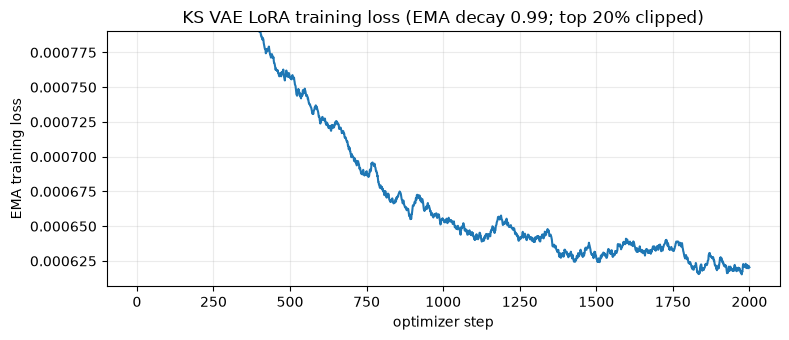

Training:   4%|▍         | 2177/50000 [17:10<4:07:49,  3.22it/s] 

In [ ]:
from tqdm import tqdm


FLUX_AWARE_LOSS_WEIGHTS = {
    "rgb": 1.0,
    "physical": 0.5,
    "initial_modes": 0.5,
    "spatial_derivative": 0.1,
    "temporal_derivative": 0.05,
    "latent_anchor": 0.01,
}


def relative_mse(prediction, target, dimensions):
    numerator = (prediction - target).square().sum(dim=dimensions)
    denominator = target.square().sum(dim=dimensions).clamp_min(1e-12)
    return (numerator / denominator).mean()


def model_tensor_to_physical(images):
    normalized = 0.5 * (images.float().mean(dim=2) + 1.0)
    vmin, vmax = KS_VALUE_BOUNDS
    return vmin + (vmax - vmin) * normalized


def normalized_flux_latents(vae, latents):
    latents = Flux2KleinPipeline._patchify_latents(latents).float()
    mean = vae.bn.running_mean.view(1, -1, 1, 1).float()
    std = torch.sqrt(
        vae.bn.running_var.view(1, -1, 1, 1).float()
        + float(vae.config.batch_norm_eps)
    )
    return (latents - mean) / std


def flux_aware_reconstruction_loss(vae, pair_pixels, reconstruction, latents, base_latents):
    reconstructed_pairs = reconstruction.reshape_as(pair_pixels)
    rgb_loss = F.mse_loss(reconstruction.float(), pair_pixels.flatten(0, 1).float())

    target_physical = model_tensor_to_physical(pair_pixels)
    reconstructed_physical = model_tensor_to_physical(reconstructed_pairs)
    target_initial = target_physical[:, 0].mean(dim=1)
    reconstructed_initial = reconstructed_physical[:, 0].mean(dim=1)
    target_solution = target_physical[:, 1]
    reconstructed_solution = reconstructed_physical[:, 1]

    initial_physical_loss = relative_mse(
        reconstructed_initial, target_initial, dimensions=(-1,)
    )
    solution_physical_loss = relative_mse(
        reconstructed_solution, target_solution, dimensions=(-2, -1)
    )
    physical_loss = 0.5 * (initial_physical_loss + solution_physical_loss)

    target_modes = torch.fft.rfft(target_initial, dim=-1)
    reconstructed_modes = torch.fft.rfft(reconstructed_initial, dim=-1)
    num_modes = min(KS_INITIAL_NUM_MODES, target_modes.shape[-1] - 1)
    mode_indices = torch.arange(1, num_modes + 1, device=target_initial.device)
    alpha = 2.0 * torch.pi * mode_indices / KS_DOMAIN_LENGTH
    growth_weights = (alpha.square() - alpha.pow(4)).clamp_min(0.0)
    mode_difference = (reconstructed_modes[:, 1 : num_modes + 1] - target_modes[:, 1 : num_modes + 1]).abs().square()
    mode_reference = target_modes[:, 1 : num_modes + 1].abs().square()
    initial_modes_loss = (
        (mode_difference * growth_weights).sum(dim=-1)
        / (mode_reference * growth_weights).sum(dim=-1).clamp_min(1e-12)
    ).mean()

    target_dx = torch.roll(target_solution, shifts=-1, dims=-1) - target_solution
    reconstructed_dx = torch.roll(reconstructed_solution, shifts=-1, dims=-1) - reconstructed_solution
    spatial_derivative_loss = relative_mse(
        reconstructed_dx, target_dx, dimensions=(-2, -1)
    )
    target_dt = target_solution[:, 1:] - target_solution[:, :-1]
    reconstructed_dt = reconstructed_solution[:, 1:] - reconstructed_solution[:, :-1]
    temporal_derivative_loss = relative_mse(
        reconstructed_dt, target_dt, dimensions=(-2, -1)
    )

    latent_anchor_loss = F.mse_loss(
        normalized_flux_latents(vae, latents),
        normalized_flux_latents(vae, base_latents).detach(),
    )
    components = {
        "rgb": rgb_loss,
        "physical": physical_loss,
        "initial_modes": initial_modes_loss,
        "spatial_derivative": spatial_derivative_loss,
        "temporal_derivative": temporal_derivative_loss,
        "latent_anchor": latent_anchor_loss,
    }
    total = sum(FLUX_AWARE_LOSS_WEIGHTS[name] * value for name, value in components.items())
    return total, components


@torch.no_grad()
def evaluate_physical_reconstruction(vae, eval_batch, pair_batch_size):
    initial_errors = []
    solution_errors = []
    all_pairs = eval_batch["pixels"]

    for pair_pixels_cpu in all_pairs.split(int(pair_batch_size)):
        pair_pixels = pair_pixels_cpu.to(
            device=device, dtype=model_dtype, non_blocking=True
        )
        pixels = pair_pixels.flatten(0, 1)
        with torch.autocast(
            device_type=device.type,
            dtype=model_dtype,
            enabled=device.type == "cuda" and model_dtype == torch.bfloat16,
        ):
            reconstruction = vae(pixels, sample_posterior=False).sample

        reconstructed_pairs = reconstruction.reshape_as(pair_pixels).float().clamp(-1.0, 1.0)
        target_physical = model_tensor_to_physical(pair_pixels)
        reconstructed_physical = model_tensor_to_physical(reconstructed_pairs)
        target_initial = target_physical[:, 0].mean(dim=1)
        reconstructed_initial = reconstructed_physical[:, 0].mean(dim=1)
        target_solution = target_physical[:, 1]
        reconstructed_solution = reconstructed_physical[:, 1]

        initial_errors.append(
            torch.linalg.vector_norm(reconstructed_initial - target_initial, dim=-1)
            / torch.linalg.vector_norm(target_initial, dim=-1).clamp_min(1e-12)
        )
        solution_errors.append(
            torch.linalg.vector_norm(
                (reconstructed_solution - target_solution).flatten(1), dim=-1
            )
            / torch.linalg.vector_norm(target_solution.flatten(1), dim=-1).clamp_min(1e-12)
        )

    initial_errors = torch.cat(initial_errors).float().cpu()
    solution_errors = torch.cat(solution_errors).float().cpu()
    return {
        "num_samples": int(initial_errors.numel()),
        "initial_mean": float(initial_errors.mean()),
        "initial_std": float(initial_errors.std(unbiased=True)),
        "solution_mean": float(solution_errors.mean()),
        "solution_std": float(solution_errors.std(unbiased=True)),
    }


def train_vae_lora(vae, loader, optimizer, cfg):
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    losses, ema_errors = [], []
    ema_error = None
    batch_iterator = iter(loader)

    for step in tqdm(range(1, cfg.max_steps + 1), desc="Training"):
        batch = next(batch_iterator)
        pair_pixels = batch["pixels"].to(
            device=device, dtype=model_dtype, non_blocking=True
        )
        # [pair batch, initial/solution, C, H, W] -> [image batch, C, H, W]
        pixels = pair_pixels.flatten(0, 1)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type=device.type,
            dtype=model_dtype,
            enabled=device.type == "cuda" and model_dtype == torch.bfloat16,
        ):
            if cfg.flux_aware_loss:
                vae.disable_adapters()
                try:
                    with torch.no_grad():
                        base_latents = vae.encode(pixels).latent_dist.mode()
                finally:
                    vae.enable_adapters()
                latents = vae.encode(pixels).latent_dist.mode()
                reconstruction = vae.decode(latents, return_dict=False)[0]
                loss, components = flux_aware_reconstruction_loss(
                    vae, pair_pixels, reconstruction, latents, base_latents
                )
            else:
                reconstruction = vae(pixels, sample_posterior=False).sample
                loss = F.mse_loss(reconstruction.float(), pixels.float())
                components = {"rgb": loss}

        component_values = {name: float(value.detach()) for name, value in components.items()}
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_parameters, cfg.max_grad_norm)
        optimizer.step()

        error = float(loss.detach())
        ema_error = error if ema_error is None else cfg.ema_decay * ema_error + (1.0 - cfg.ema_decay) * error
        losses.append(error)
        ema_errors.append(ema_error)

        if step % cfg.plot_every == 0:
            clear_output(wait=True)
            seeds = batch["seed"].tolist()
            component_text = " | ".join(
                f"{name}={value:.4g}" for name, value in component_values.items()
            )
            print(f"step {step:,}/{cfg.max_steps:,} | loss {error:.6g} | EMA {ema_error:.6g} | seeds {seeds}")
            print(component_text)
            print(f"Evaluating physical reconstruction on {cfg.debug_num_samples} fixed samples...")
            physical_error = evaluate_physical_reconstruction(
                vae,
                fixed_eval_batch,
                pair_batch_size=min(cfg.debug_num_samples, max(4, cfg.batch_size)),
            )
            print(
                f"physical relative L2 at step {step:,} "
                f"(n={physical_error['num_samples']}): "
                f"initial={100.0 * physical_error['initial_mean']:.6f}% +/- "
                f"{100.0 * physical_error['initial_std']:.6f}%, "
                f"solution={100.0 * physical_error['solution_mean']:.6f}% +/- "
                f"{100.0 * physical_error['solution_std']:.6f}%"
            )
            plot_ema_error(ema_errors, cfg.ema_decay)

        if cfg.save_every and step % cfg.save_every == 0:
            save_vae_lora_adapter(
                vae,
                output_dir,
                weight_name=f"step-{step:06d}.safetensors",
            )

    save_vae_lora_adapter(
        vae,
        output_dir,
        weight_name="pytorch_lora_weights.safetensors",
    )
    return {"loss": losses, "ema_error": ema_errors}


history = train_vae_lora(vae, loader, optimizer, config)